In [14]:
import pandas as pd
import numpy as np
from dash import Dash, dcc, html
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

# Load dataset (use your generated CSV)
data = pd.read_csv("simulated_dht22_data_large.csv")

# Prepare variables
X = data["Temperature"].values.reshape(-1, 1)
y = data["Humidity"].values

# Train Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Regression line data
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_range = model.predict(x_range)

# Create scatter plot with regression line
fig = px.scatter(data, x="Temperature", y="Humidity", opacity=0.7, title="Temperature vs Humidity (Linear Regression)")
fig.add_traces(go.Scatter(x=x_range.flatten(), y=y_range, name="Regression Line", line=dict(color="red")))

# Dash app
app = Dash(__name__)
app.layout = html.Div([
    html.H1("DHT22 Sensor Data - Linear Regression", style={"textAlign": "center"}),
    dcc.Graph(figure=fig),
    html.Div([
        html.P(f"Regression Equation: Humidity = {model.coef_[0]:.2f} * Temperature + {model.intercept_:.2f}"),
        html.P(f"R² Score: {model.score(X, y):.3f}")
    ], style={"textAlign": "center", "fontSize": 18, "marginTop": "20px"})
])

if __name__ == "__main__":
    app.run(debug=True)



In [12]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# Load your dataset (replace with your filename)
data = pd.read_csv("simulated_dht22_data.csv")

# Features and labels
X = data["Temperature"].values.reshape(-1, 1)
y = data["Humidity"].values

# Train the model
model = LinearRegression()
model.fit(X, y)

# Step 4: Find min & max temperature
min_temp = X.min()
max_temp = X.max()

# Generate 100 equally spaced temperature values
test_temps = np.linspace(min_temp, max_temp, 100).reshape(-1, 1)

# Predict humidity for these 100 values
predicted_humidity = model.predict(test_temps)

# Create DataFrame to save results
results = pd.DataFrame({
    "Temperature": test_temps.flatten(),
    "Predicted_Humidity": predicted_humidity
})

print(results.head(10))   # Show first 10 predictions
print(results.tail(10))   # Show last 10 predictions


   Temperature  Predicted_Humidity
0    14.100000           81.636014
1    14.262626           81.387371
2    14.425253           81.138728
3    14.587879           80.890085
4    14.750505           80.641441
5    14.913131           80.392798
6    15.075758           80.144155
7    15.238384           79.895512
8    15.401010           79.646869
9    15.563636           79.398226
    Temperature  Predicted_Humidity
90    28.736364           59.258130
91    28.898990           59.009486
92    29.061616           58.760843
93    29.224242           58.512200
94    29.386869           58.263557
95    29.549495           58.014914
96    29.712121           57.766271
97    29.874747           57.517627
98    30.037374           57.268984
99    30.200000           57.020341


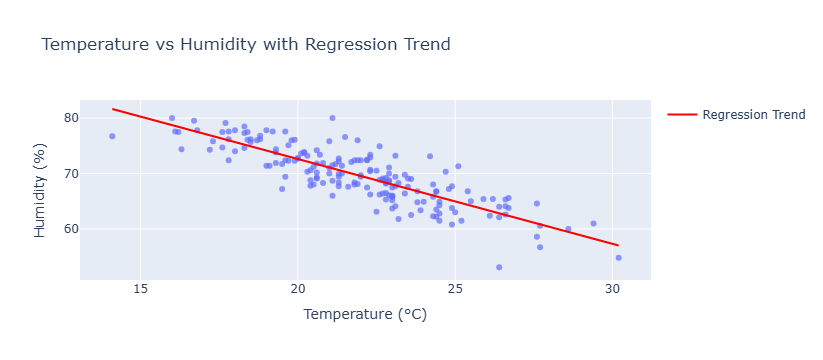

In [13]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import plotly.express as px
import plotly.graph_objects as go

# ---------------------------
# 1. Load CSV data
# ---------------------------
df = pd.read_csv("simulated_dht22_data.csv")  # Replace with your file
X = df["Temperature"].values.reshape(-1, 1)
y = df["Humidity"].values

# ---------------------------
# 2. Train Linear Regression
# ---------------------------
model = LinearRegression()
model.fit(X, y)

# ---------------------------
# 3. Interpolate 100 test values
# ---------------------------
min_temp = df["Temperature"].min()
max_temp = df["Temperature"].max()
test_temps = np.linspace(min_temp, max_temp, 100).reshape(-1, 1)
predicted_humidity = model.predict(test_temps)

# ---------------------------
# 4. Plot scatter + regression line
# ---------------------------
fig = px.scatter(df, x="Temperature", y="Humidity",
                 title="Temperature vs Humidity with Regression Trend",
                 opacity=0.7, labels={"Temperature": "Temperature (°C)", "Humidity": "Humidity (%)"})

# Add regression line
fig.add_trace(go.Scatter(x=test_temps.flatten(), y=predicted_humidity,
                         mode="lines", name="Regression Trend", line=dict(color="red")))

fig.show()


Original dataset size: 180
Filtered dataset size: 179


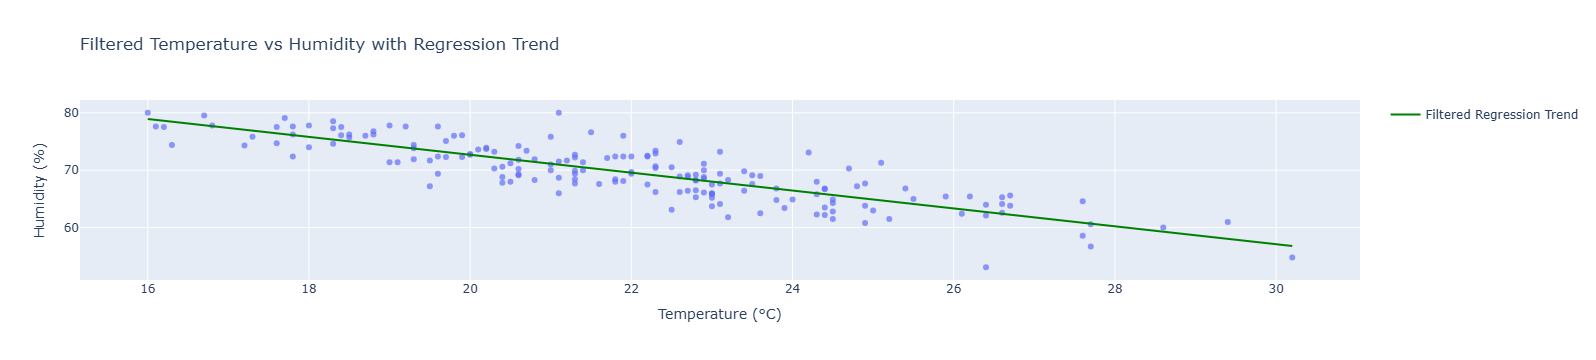

In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import plotly.express as px
import plotly.graph_objects as go

# ---------------------------
# 1. Load CSV data
# ---------------------------
df = pd.read_csv("simulated_dht22_data.csv")  

# ---------------------------
# 2. Filter extremes (outliers)
# ---------------------------
# Define thresholds for filtering (you can adjust these manually)
min_temp_threshold = 15   # remove very low temperatures
max_temp_threshold = 35   # remove very high temperatures

# Apply filter
filtered_df = df[(df["Temperature"] >= min_temp_threshold) & 
                 (df["Temperature"] <= max_temp_threshold)]

print(f"Original dataset size: {len(df)}")
print(f"Filtered dataset size: {len(filtered_df)}")

# ---------------------------
# 3. Train Linear Regression on filtered data
# ---------------------------
X = filtered_df["Temperature"].values.reshape(-1, 1)
y = filtered_df["Humidity"].values

model = LinearRegression()
model.fit(X, y)

# Generate test values
test_temps = np.linspace(filtered_df["Temperature"].min(),
                         filtered_df["Temperature"].max(), 100).reshape(-1, 1)
predicted_humidity = model.predict(test_temps)

# ---------------------------
# 4. Plot scatter + regression line
# ---------------------------
fig = px.scatter(filtered_df, x="Temperature", y="Humidity",
                 title="Filtered Temperature vs Humidity with Regression Trend",
                 opacity=0.7, labels={"Temperature": "Temperature (°C)", "Humidity": "Humidity (%)"})

# Add regression line
fig.add_trace(go.Scatter(x=test_temps.flatten(), y=predicted_humidity,
                         mode="lines", name="Filtered Regression Trend", line=dict(color="green")))

fig.show()


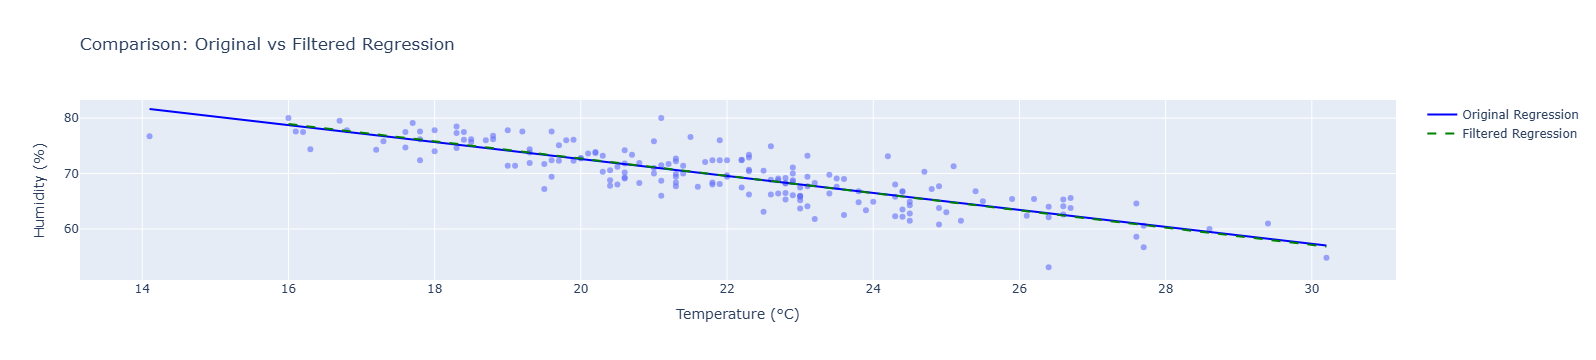

Original Regression: Slope = -1.5289237873176982 Intercept = 103.19383951294597
Filtered Regression: Slope = -1.5567659361338522 Intercept = 103.8333045595361


In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import plotly.express as px
import plotly.graph_objects as go

# ---------------------------
# 1. Load CSV data
# ---------------------------
df = pd.read_csv("simulated_dht22_data.csv")

# ---------------------------
# 2. Train LR on original data
# ---------------------------
X_orig = df["Temperature"].values.reshape(-1, 1)
y_orig = df["Humidity"].values

model_orig = LinearRegression()
model_orig.fit(X_orig, y_orig)

# Generate test values for original
test_temps_orig = np.linspace(df["Temperature"].min(),
                              df["Temperature"].max(), 100).reshape(-1, 1)
pred_humidity_orig = model_orig.predict(test_temps_orig)

# ---------------------------
# 3. Filter extremes and retrain LR
# ---------------------------
min_temp_threshold = 15
max_temp_threshold = 35

filtered_df = df[(df["Temperature"] >= min_temp_threshold) & 
                 (df["Temperature"] <= max_temp_threshold)]

X_filt = filtered_df["Temperature"].values.reshape(-1, 1)
y_filt = filtered_df["Humidity"].values

model_filt = LinearRegression()
model_filt.fit(X_filt, y_filt)

# Generate test values for filtered
test_temps_filt = np.linspace(filtered_df["Temperature"].min(),
                              filtered_df["Temperature"].max(), 100).reshape(-1, 1)
pred_humidity_filt = model_filt.predict(test_temps_filt)

# ---------------------------
# 4. Plot comparison
# ---------------------------
fig = px.scatter(df, x="Temperature", y="Humidity",
                 title="Comparison: Original vs Filtered Regression",
                 opacity=0.6, labels={"Temperature": "Temperature (°C)", "Humidity": "Humidity (%)"})

# Original regression line
fig.add_trace(go.Scatter(x=test_temps_orig.flatten(), y=pred_humidity_orig,
                         mode="lines", name="Original Regression", line=dict(color="blue")))

# Filtered regression line
fig.add_trace(go.Scatter(x=test_temps_filt.flatten(), y=pred_humidity_filt,
                         mode="lines", name="Filtered Regression", line=dict(color="green", dash="dash")))

fig.show()

# ---------------------------
# 5. Print slope and intercept for comparison
# ---------------------------
print("Original Regression: Slope =", model_orig.coef_[0], "Intercept =", model_orig.intercept_)
print("Filtered Regression: Slope =", model_filt.coef_[0], "Intercept =", model_filt.intercept_)


### Analysis of Regression Lines: Original vs Filtered Data

- The original regression line has a slope of **-1.529** and intercept **103.19**, while the filtered regression line has a slope of **-1.557** and intercept **103.83**.  
- The slight change in slope and intercept indicates that **removing extreme temperature values (outliers) slightly adjusted the regression line**.  
- Both regression lines show the same general trend: **humidity decreases as temperature increases**.  
- Filtering out outliers allowed the linear regression model to **better represent the majority of the data points**, providing a more accurate trend without changing the overall negative correlation pattern.


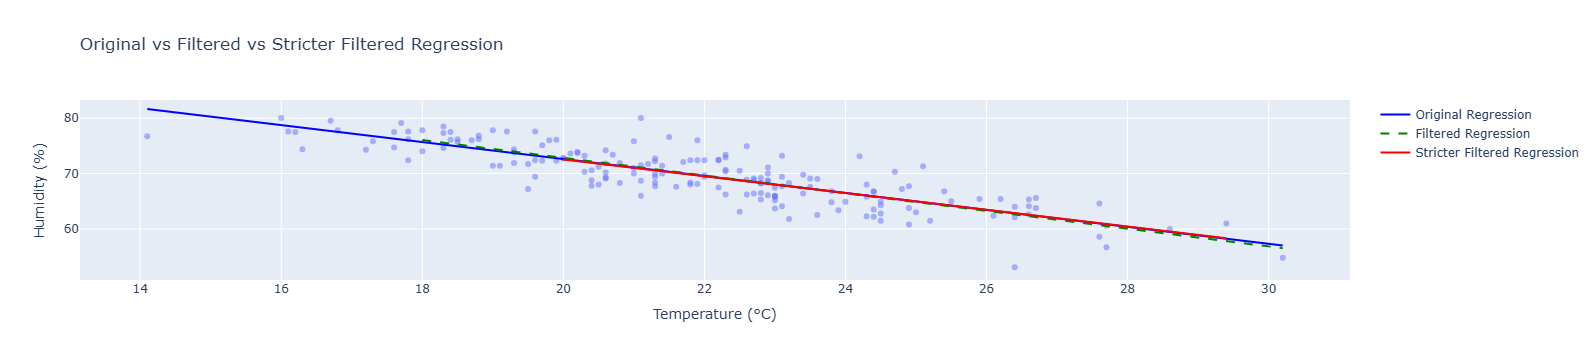

Original Regression: Slope = -1.5289237873176982 Intercept = 103.19383951294597
Filtered Regression: Slope = -1.5976143689658384 Intercept = 104.79263692926529
Stricter Filtered Regression: Slope = -1.5081370722088596 Intercept = 102.68317835830919


In [10]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import plotly.express as px
import plotly.graph_objects as go

# ---------------------------
# 1. Load CSV data
# ---------------------------
df = pd.read_csv("simulated_dht22_data.csv")

# ---------------------------
# 2. Original Data
# ---------------------------
X_orig = df["Temperature"].values.reshape(-1, 1)
y_orig = df["Humidity"].values

model_orig = LinearRegression()
model_orig.fit(X_orig, y_orig)

# Test values for original data
test_temps_orig = np.linspace(df["Temperature"].min(), df["Temperature"].max(), 100).reshape(-1, 1)
pred_humidity_orig = model_orig.predict(test_temps_orig)

# ---------------------------
# 3. Filtered Data (remove 5-10 outliers)
# ---------------------------
min_temp_filt = 18
max_temp_filt = 32
filtered_df = df[(df["Temperature"] >= min_temp_filt) & (df["Temperature"] <= max_temp_filt)]

X_filt = filtered_df["Temperature"].values.reshape(-1, 1)
y_filt = filtered_df["Humidity"].values

model_filt = LinearRegression()
model_filt.fit(X_filt, y_filt)

test_temps_filt = np.linspace(filtered_df["Temperature"].min(),
                              filtered_df["Temperature"].max(), 100).reshape(-1, 1)
pred_humidity_filt = model_filt.predict(test_temps_filt)

# ---------------------------
# 4. Stricter Filtered Data (remove more outliers)
# ---------------------------
min_temp_strict = 20
max_temp_strict = 30
strict_filtered_df = df[(df["Temperature"] >= min_temp_strict) & (df["Temperature"] <= max_temp_strict)]

X_strict = strict_filtered_df["Temperature"].values.reshape(-1, 1)
y_strict = strict_filtered_df["Humidity"].values

model_strict = LinearRegression()
model_strict.fit(X_strict, y_strict)

test_temps_strict = np.linspace(strict_filtered_df["Temperature"].min(),
                                strict_filtered_df["Temperature"].max(), 100).reshape(-1, 1)
pred_humidity_strict = model_strict.predict(test_temps_strict)

# ---------------------------
# 5. Plot comparison
# ---------------------------
fig = px.scatter(df, x="Temperature", y="Humidity",
                 title="Original vs Filtered vs Stricter Filtered Regression",
                 opacity=0.5, labels={"Temperature":"Temperature (°C)", "Humidity":"Humidity (%)"})

# Original Regression line
fig.add_trace(go.Scatter(x=test_temps_orig.flatten(), y=pred_humidity_orig,
                         mode="lines", name="Original Regression", line=dict(color="blue")))

# Filtered Regression line
fig.add_trace(go.Scatter(x=test_temps_filt.flatten(), y=pred_humidity_filt,
                         mode="lines", name="Filtered Regression", line=dict(color="green", dash="dash")))

# Stricter Filtered Regression line
fig.add_trace(go.Scatter(x=test_temps_strict.flatten(), y=pred_humidity_strict,
                         mode="lines", name="Stricter Filtered Regression", line=dict(color="red")))

fig.show()

# ---------------------------
# 6. Print slope and intercepts
# ---------------------------
print("Original Regression: Slope =", model_orig.coef_[0], "Intercept =", model_orig.intercept_)
print("Filtered Regression: Slope =", model_filt.coef_[0], "Intercept =", model_filt.intercept_)
print("Stricter Filtered Regression: Slope =", model_strict.coef_[0], "Intercept =", model_strict.intercept_)


### Insight on Regression Trend Lines

**Original Regression:**  
- Slope = -1.529, Intercept = 103.19  
- The trend line captures the overall negative correlation between temperature and humidity but may be influenced by outliers at extreme temperatures.

**Filtered Regression (some outliers removed):**  
- Slope = -1.598, Intercept = 104.79  
- Removing extreme values slightly increased the magnitude of the slope.  
- This indicates the model learned a slightly steeper negative relationship as the outliers that flattened the line were removed.

**Stricter Filtered Regression (more outliers removed):**  
- Slope = -1.508, Intercept = 102.68  
- With further outlier removal, the slope slightly decreased compared to the filtered regression but is still close to the original trend.  
- This suggests the regression model is robust; the main trend of decreasing humidity with increasing temperature remains consistent.

**Overall Observation:**  
- The trend line remains negative in all cases, indicating a stable negative correlation.  
- Outliers mainly affect the slope and intercept, causing slight variations.  
- Filtering out outliers helps the model learn a more accurate and cleaner pattern of the underlying data.
